# Chapter 9: Structure of Semisimple Lie Groups

**Source Span.** Helgason, *Differential Geometry, Lie Groups, and Symmetric Spaces*, Chapter IX, printed pages `401-437` (approximate PDF pages `428-464`). The course `source_map.json` records the focus as Cartan, Iwasawa, Bruhat, rank-one, `SU(2,1)`, Cartan subalgebras, automorphisms, multiplicities, and Jordan decompositions.

**Chapter goal.** Learn how the algebraic data of a noncompact semisimple group becomes computable coordinates: a Weyl chamber gives the unique Cartan part, positive restricted roots build `N`, Weyl group representatives stratify the Bruhat cells, rank-one subalgebras reduce computations, and Jordan pieces explain why elliptic, hyperbolic, and unipotent elements land near `K`, `A`, and `N`.

This notebook is standalone. It uses the source span for terminology and theorem orientation only; the explanations, examples, diagrams, and checks are original computational models. The recurring inspection question is: *where does a theorem store the part of the group that remains unique after the nonunique factors have moved around it?*


## Visual Storyboard

**Concept inventory.** Restricted roots and Weyl chambers; the refined Cartan decomposition `G = K A+ K`; Iwasawa coordinates `G = K A N`; Bruhat cells `B m_s B`; the big cell and lower-dimensional boundary strata; rank-one subalgebras `g_alpha`; the `SU(2,1)` reduction and its explicit `A+`, `H`, and `B` formulas; Cartan subalgebras of a real semisimple algebra and their finite conjugacy classes; automorphisms of compact real forms through root-system automorphisms; multiplicity parity and split rank; complete multiplicative Jordan decomposition; and the `sl(2,R)` triple attached to nilpotent elements.

**Proof-visualization strategy.** The proof graph below tracks which facts feed later facts. The matrix experiments do not prove Helgason's theorems, but they expose the invariants the proofs protect: chamber representatives, triangular factors, permutation strata, root-string closure, parity, and commuting Jordan components.

**Visual sequence.**

| Visual | Chapter concept | Representation | Validation target |
| --- | --- | --- | --- |
| Proof dependency graph | How the sections depend on each other | NetworkX directed graph | Graph is connected and acyclic |
| Cartan chamber projection | `K A+ K` uniqueness | `A2` Weyl orbit in a chamber | Every orbit has one sorted chamber representative |
| Iwasawa matrix factorization | `K A N` coordinates | QR-based `SL(3,R)` factorization | Orthogonality, determinant, reconstruction residual |
| Bruhat cell order | `B m_s B` strata | `S3` Bruhat Hasse diagram | Six Weyl cells, unique open cell |
| Rank-one root reduction | `g_alpha` as microscope | Root-string and bracket-degree diagram | Bracket degrees close inside the rank-one string |
| `SU(2,1)` formula surface | Rank-one explicit components | Heat maps for `A+`, `H`, and `B` | The formula relation has near-zero residual |
| Cartan and automorphism panels | Cartan subalgebras and outer symmetries | `sl(2,R)` classifier and `A2` root hexagon | Semisimple versus nilpotent and `Aut(Delta)/W` size |
| Multiplicity parity ledger | Theorem 6.1 | Example table and parity bars | Split-rank equality matches even multiplicities |
| Jordan decomposition panel | Section 7 | Commuting matrix factors and `sl2` triple | Factors commute and the triple identities hold |
| Applied lab | `SU(2,1)` parameter sensitivity | Parameter sweep table/plot | Monotonicity and big-cell boundary checks |


In [1]:
from pathlib import Path
import csv
import itertools
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
from IPython.display import Markdown, display

COURSE_FOLDER = "Differential-Geometry-Lie-Groups-and-Symmetric-Spaces"

def locate_book_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
            return candidate
        nested = candidate / COURSE_FOLDER
        if (nested / "AGENTS.md").exists() and (nested / "source_map.json").exists():
            return nested
    raise RuntimeError("Could not locate the Helgason course root")

BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-09-structure-of-semisimple-lie-groups"
UNIT_TITLE = "Structure of Semisimple Lie Groups"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
HTML = ARTIFACT_ROOT / "html"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

def display_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    rule = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(str(row.get(col, "")) for col in columns) + " |" for row in rows]
    display(Markdown("\n".join([header, rule, *body])))

print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT}")


Book root: D:\Geometry\Differential-Geometry-Lie-Groups-and-Symmetric-Spaces
Artifact root: D:\Geometry\Differential-Geometry-Lie-Groups-and-Symmetric-Spaces\artifacts\chapter-09-structure-of-semisimple-lie-groups


## Library Routing

The chapter is algebraic and proof-heavy, so the smallest faithful stack is matrix algebra plus graph and 2D visualizations. Matplotlib handles durable chamber/root diagrams and matrix panels; NetworkX handles dependency and Bruhat order graphs; SymPy verifies exact bracket identities; NumPy verifies numerical matrix decompositions and formula sweeps. No 3D mesh, topology, CV, OT, or GIS library is needed for this chapter's geometry.


In [2]:
library_routing = [
    {
        "concept": "chapter proof dependencies",
        "representation": "directed graph",
        "library": "NetworkX + Matplotlib",
        "why": "the proof structure is a finite dependency relation",
        "artifact": "figures/chapter09-proof-dependency-graph.png",
        "check": "checks/chapter09-proof-dependency-graph.json",
    },
    {
        "concept": "Cartan chamber uniqueness",
        "representation": "A2 Weyl orbit and chamber inequalities",
        "library": "NumPy + Matplotlib",
        "why": "rank-two chamber geometry is planar and exactly inspectable",
        "artifact": "figures/cartan-weyl-chamber-unique-projection.png",
        "check": "checks/cartan-weyl-chamber-unique-projection.json",
    },
    {
        "concept": "Iwasawa decomposition",
        "representation": "SL(3,R) matrix factorization panels",
        "library": "NumPy + Matplotlib",
        "why": "QR with positive diagonal is a concrete KAN model",
        "artifact": "figures/iwasawa-sl3-factorization.png",
        "check": "checks/iwasawa-sl3-factorization.json",
    },
    {
        "concept": "Bruhat decomposition",
        "representation": "S3 Bruhat order graph",
        "library": "NetworkX + Matplotlib",
        "why": "Weyl group cells are finite combinatorial strata",
        "artifact": "figures/bruhat-s3-cell-order.png",
        "check": "checks/bruhat-s3-cell-order.json",
    },
    {
        "concept": "rank-one and SU(2,1) reductions",
        "representation": "root string and formula heat maps",
        "library": "NumPy + Matplotlib",
        "why": "rank-one formulas are scalar functions of root coordinates",
        "artifact": "figures/su21-iwasawa-bruhat-formulas.png",
        "check": "checks/su21-iwasawa-bruhat-formulas.json",
    },
    {
        "concept": "Cartan subalgebras, automorphisms, multiplicities, Jordan pieces",
        "representation": "small exact matrix/root-system checks",
        "library": "SymPy + NumPy + Matplotlib",
        "why": "these sections are finite algebraic identities and parity ledgers",
        "artifact": "figures/jordan-components-and-sl2-triple.png",
        "check": "checks/jordan-components-and-sl2-triple.json",
    },
]

storyboard = {
    "chapter_goal": "Turn Chapter IX structure theorems into inspectable coordinates, strata, reductions, and invariant checks.",
    "source_span_read": {
        "pdf": "Differential Geometry, Lie Groups, and Symmetric Spaces.pdf",
        "printed_pages": "401-437",
        "approx_pdf_pages": "428-464",
        "source_map_focus": "Cartan, Iwasawa, Bruhat, rank-one, SU(2,1), Cartan subalgebras, automorphisms, multiplicities, and Jordan decompositions",
    },
    "visual_sequence": [
        "figures/chapter09-proof-dependency-graph.png",
        "figures/cartan-weyl-chamber-unique-projection.png",
        "figures/iwasawa-sl3-factorization.png",
        "figures/bruhat-s3-cell-order.png",
        "figures/rank-one-root-reduction.png",
        "figures/su21-iwasawa-bruhat-formulas.png",
        "figures/cartan-subalgebra-and-root-automorphism.png",
        "figures/multiplicity-parity-split-rank-ledger.png",
        "figures/jordan-components-and-sl2-triple.png",
        "figures/applied-lab-su21-parameter-sweep.png",
    ],
    "computational_checks": [
        "Cartan chamber representative inequalities",
        "SL(3,R) KAN reconstruction residual",
        "S3 Bruhat cell counts and open cell",
        "rank-one bracket-degree closure",
        "SU(2,1) formula residual",
        "sl(2,R) Cartan classifier eigenvalue checks",
        "multiplicity parity versus split-rank equality",
        "commuting complete Jordan factors and sl2 triple identities",
    ],
    "copyright_note": "No textbook prose, exercises, figures, screenshots, or page crops are copied.",
}
source_coverage = {
    "sections": [
        {"section": "1", "covered_by": ["Cartan chamber", "Iwasawa panels", "Bruhat S3 cells"]},
        {"section": "2", "covered_by": ["rank-one root string"]},
        {"section": "3", "covered_by": ["SU(2,1) formula surface", "applied lab"]},
        {"section": "4", "covered_by": ["sl(2,R) Cartan classifier"]},
        {"section": "5", "covered_by": ["A2 root automorphism panel"]},
        {"section": "6", "covered_by": ["multiplicity parity ledger"]},
        {"section": "7", "covered_by": ["Jordan decomposition panel", "sl2 triple check"]},
    ],
    "source_use": "orientation, terminology, theorem sequence, and page span only",
}

storyboard_path = save_json(storyboard, CHECKS / "visual-storyboard.json")
source_coverage_path = save_json(source_coverage, CHECKS / "source-coverage.json")
routing_path = save_csv(library_routing, TABLES / "library-routing.csv")

display_table(library_routing, ["concept", "representation", "library", "why", "artifact", "check"])
display_artifact(routing_path)
display_artifact(storyboard_path)


| concept | representation | library | why | artifact | check |
| --- | --- | --- | --- | --- | --- |
| chapter proof dependencies | directed graph | NetworkX + Matplotlib | the proof structure is a finite dependency relation | figures/chapter09-proof-dependency-graph.png | checks/chapter09-proof-dependency-graph.json |
| Cartan chamber uniqueness | A2 Weyl orbit and chamber inequalities | NumPy + Matplotlib | rank-two chamber geometry is planar and exactly inspectable | figures/cartan-weyl-chamber-unique-projection.png | checks/cartan-weyl-chamber-unique-projection.json |
| Iwasawa decomposition | SL(3,R) matrix factorization panels | NumPy + Matplotlib | QR with positive diagonal is a concrete KAN model | figures/iwasawa-sl3-factorization.png | checks/iwasawa-sl3-factorization.json |
| Bruhat decomposition | S3 Bruhat order graph | NetworkX + Matplotlib | Weyl group cells are finite combinatorial strata | figures/bruhat-s3-cell-order.png | checks/bruhat-s3-cell-order.json |
| rank-one and SU(2,1) reductions | root string and formula heat maps | NumPy + Matplotlib | rank-one formulas are scalar functions of root coordinates | figures/su21-iwasawa-bruhat-formulas.png | checks/su21-iwasawa-bruhat-formulas.json |
| Cartan subalgebras, automorphisms, multiplicities, Jordan pieces | small exact matrix/root-system checks | SymPy + NumPy + Matplotlib | these sections are finite algebraic identities and parity ledgers | figures/jordan-components-and-sl2-triple.png | checks/jordan-components-and-sl2-triple.json |

[library-routing.csv](artifacts/chapter-09-structure-of-semisimple-lie-groups/tables/library-routing.csv)

`visual-storyboard.json`

## Translation Guide: From Chapter Language To Computation

`K`, `A`, and `N` should not be read as arbitrary letters. In the noncompact semisimple setting they separate three different kinds of information.

- `K` absorbs compact angular ambiguity.
- `A` records the abelian noncompact displacement. A closed Weyl chamber `A+` makes the Cartan part unique.
- `N` records positive-root nilpotent shear. Choosing positive restricted roots chooses the direction of this shear.
- `B = M A N` packages the triangular part for Bruhat double cosets.
- The Weyl group `W = M'/M` decides both chamber folding and Bruhat strata.

The notebook repeatedly uses small models. `SL(3,R)` illustrates chamber, Iwasawa, and Bruhat behavior. Rank-one and `SU(2,1)` panels illustrate the reduction principle. `sl(2,R)` and finite root systems then carry the Cartan-subalgebra, automorphism, multiplicity, and Jordan checks.


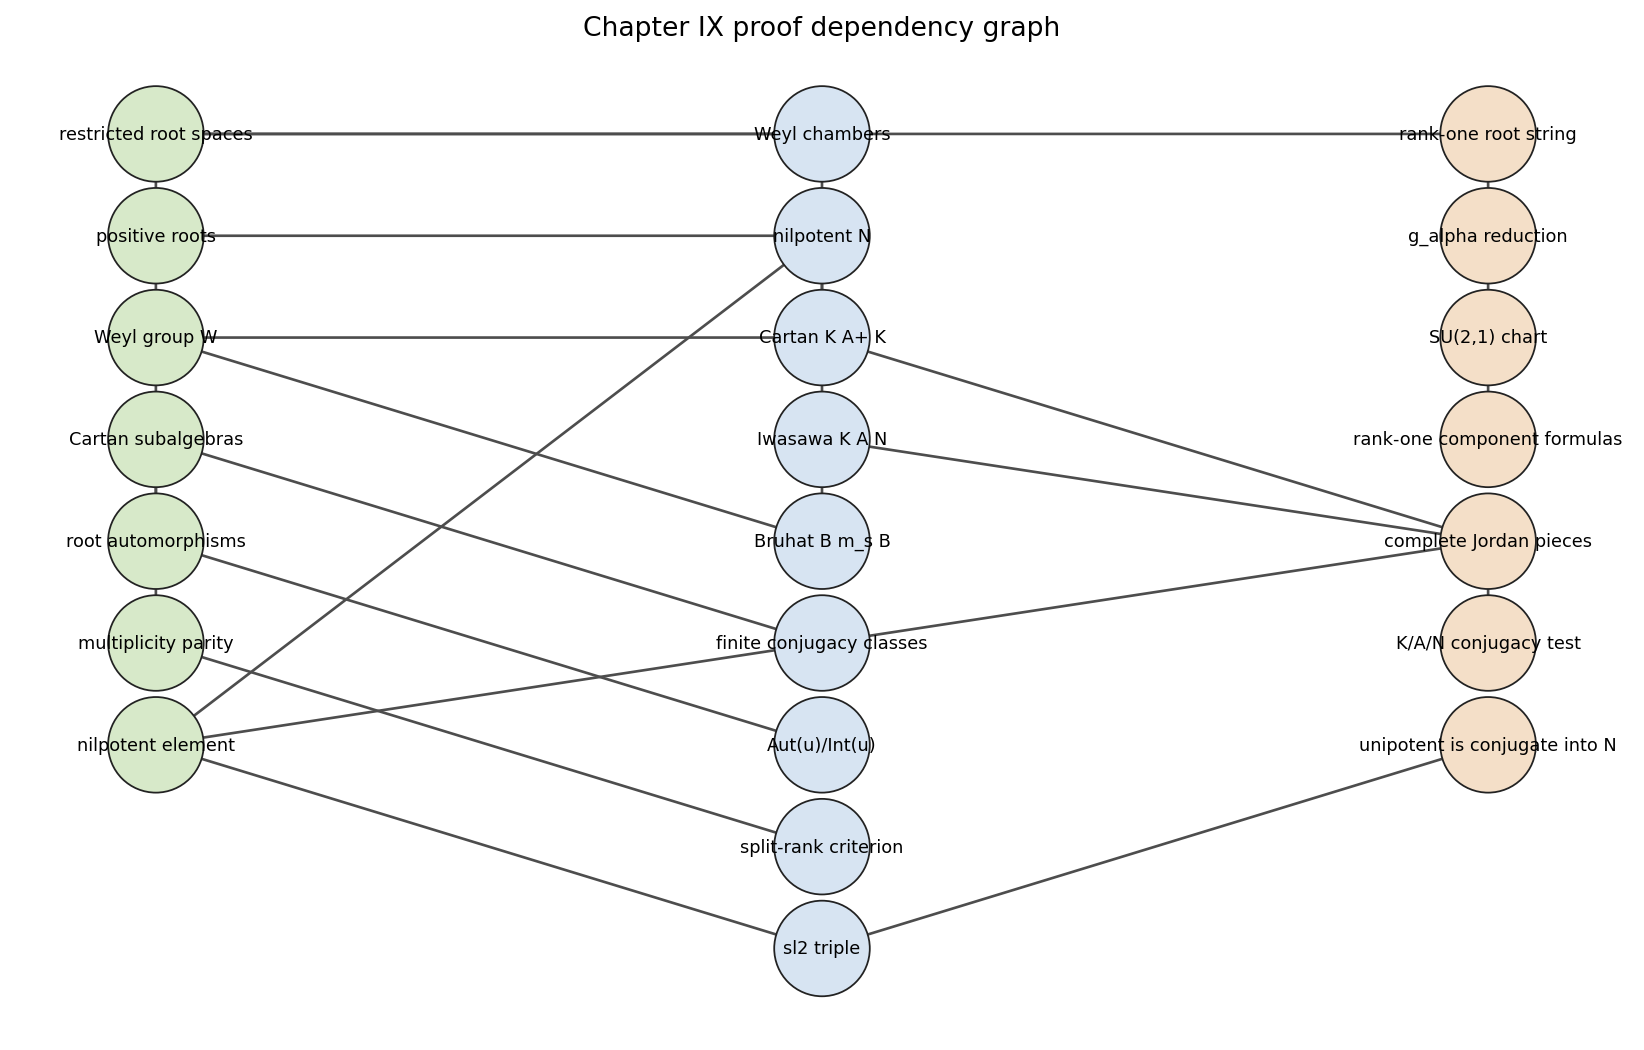

{'node_count': 23,
 'edge_count': 24,
 'weakly_connected': True,
 'acyclic': True,
 'sinks': ['Bruhat B m_s B',
  'rank-one component formulas',
  'finite conjugacy classes',
  'Aut(u)/Int(u)',
  'split-rank criterion',
  'unipotent is conjugate into N',
  'K/A/N conjugacy test']}

In [3]:
dependency_edges = [
    ("restricted root spaces", "Weyl chambers"),
    ("restricted root spaces", "rank-one root string"),
    ("restricted root spaces", "Cartan subalgebras"),
    ("Weyl chambers", "Cartan K A+ K"),
    ("positive roots", "nilpotent N"),
    ("nilpotent N", "Iwasawa K A N"),
    ("nilpotent N", "nilpotent element"),
    ("Iwasawa K A N", "Bruhat B m_s B"),
    ("Weyl group W", "Cartan K A+ K"),
    ("Weyl group W", "Bruhat B m_s B"),
    ("rank-one root string", "g_alpha reduction"),
    ("g_alpha reduction", "SU(2,1) chart"),
    ("SU(2,1) chart", "rank-one component formulas"),
    ("Cartan subalgebras", "finite conjugacy classes"),
    ("Cartan subalgebras", "root automorphisms"),
    ("Cartan subalgebras", "multiplicity parity"),
    ("root automorphisms", "Aut(u)/Int(u)"),
    ("multiplicity parity", "split-rank criterion"),
    ("nilpotent element", "sl2 triple"),
    ("sl2 triple", "unipotent is conjugate into N"),
    ("complete Jordan pieces", "K/A/N conjugacy test"),
    ("complete Jordan pieces", "nilpotent element"),
    ("Cartan K A+ K", "complete Jordan pieces"),
    ("Iwasawa K A N", "complete Jordan pieces"),
]
DG = nx.DiGraph()
DG.add_edges_from(dependency_edges)
layers = {
    "roots": ["restricted root spaces", "positive roots", "Weyl group W", "Cartan subalgebras", "root automorphisms", "multiplicity parity", "nilpotent element"],
    "decompositions": ["Weyl chambers", "nilpotent N", "Cartan K A+ K", "Iwasawa K A N", "Bruhat B m_s B", "finite conjugacy classes", "Aut(u)/Int(u)", "split-rank criterion", "sl2 triple"],
    "reductions": ["rank-one root string", "g_alpha reduction", "SU(2,1) chart", "rank-one component formulas", "complete Jordan pieces", "K/A/N conjugacy test", "unipotent is conjugate into N"],
}
pos = {}
for x, (_, nodes) in enumerate(layers.items()):
    for y, node in enumerate(nodes):
        pos[node] = (x, -y)
for node in DG:
    pos.setdefault(node, (1.5, -len(pos)))

fig, ax = plt.subplots(figsize=(13, 8))
node_colors = []
for node in DG.nodes:
    if node in layers["roots"]:
        node_colors.append("#d7e9c9")
    elif node in layers["decompositions"]:
        node_colors.append("#d7e4f2")
    else:
        node_colors.append("#f4dfc8")
nx.draw_networkx_edges(DG, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.2, edge_color="#4d4d4d")
nx.draw_networkx_nodes(DG, pos, ax=ax, node_color=node_colors, node_size=1850, edgecolors="#222222", linewidths=0.8)
nx.draw_networkx_labels(DG, pos, ax=ax, font_size=8)
ax.set_title("Chapter IX proof dependency graph")
ax.axis("off")
proof_graph_path = save_matplotlib(fig, FIGURES / "chapter09-proof-dependency-graph.png")
plt.close(fig)

proof_graph_check = {
    "node_count": DG.number_of_nodes(),
    "edge_count": DG.number_of_edges(),
    "weakly_connected": nx.is_weakly_connected(DG),
    "acyclic": nx.is_directed_acyclic_graph(DG),
    "sinks": [node for node in DG.nodes if DG.out_degree(node) == 0],
}
proof_graph_check_path = save_json(proof_graph_check, CHECKS / "chapter09-proof-dependency-graph.json")
display_artifact(proof_graph_path, width=900)
proof_graph_check


## 1. Cartan Projection: Folding To One Weyl Chamber

The refined Cartan decomposition says that the noncompact displacement of `g` has a unique representative in the closed positive chamber. The factors in `K` can vary, but the chamber point cannot. For `SL(3,R)`, the model chamber is the set of trace-zero diagonal triples with `h1 >= h2 >= h3`; the Weyl group permutes the three entries.

Inspect the orbit below as a chamber-folding machine. The same Euclidean norm appears at every Weyl image, but only one image satisfies both simple-root inequalities.


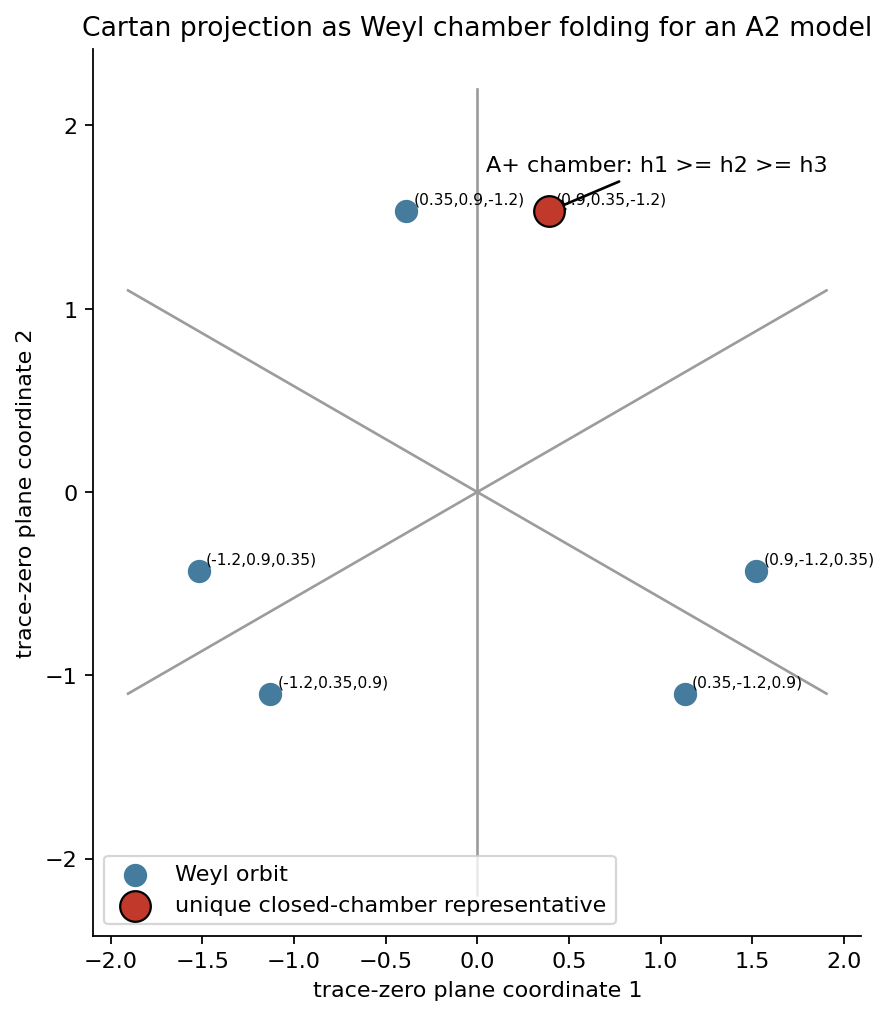

{'original_H': [0.35, -1.25, 0.9],
 'orbit_size': 6,
 'chamber_representative': [0.9, 0.35, -1.25],
 'simple_root_values': {'alpha_1=h1-h2': 0.55, 'alpha_2=h2-h3': 1.6},
 'all_orbit_norms_equal': True,
 'representative_in_closed_positive_chamber': True,
 'unique_representatives_in_chamber': 1}

In [4]:
e1 = np.array([1.0, -1.0, 0.0]) / math.sqrt(2)
e2 = np.array([1.0, 1.0, -2.0]) / math.sqrt(6)

def project_a2(v):
    v = np.array(v, dtype=float)
    return np.array([np.dot(v, e1), np.dot(v, e2)])

H0 = np.array([0.35, -1.25, 0.90])
H0 = H0 - H0.mean()
orbit = sorted({tuple(np.array(p) - np.mean(p)) for p in itertools.permutations(H0)})
chamber_rep = np.array(sorted(H0, reverse=True))
simple_values = {
    "alpha_1=h1-h2": float(chamber_rep[0] - chamber_rep[1]),
    "alpha_2=h2-h3": float(chamber_rep[1] - chamber_rep[2]),
}

roots = [
    np.array([1.0, -1.0, 0.0]),
    np.array([0.0, 1.0, -1.0]),
    np.array([1.0, 0.0, -1.0]),
]
fig, ax = plt.subplots(figsize=(7.8, 7.2))
radius = 2.2
for root in roots:
    normal = project_a2(root)
    direction = np.array([-normal[1], normal[0]])
    direction = direction / np.linalg.norm(direction)
    pts = np.vstack([-radius * direction, radius * direction])
    ax.plot(pts[:, 0], pts[:, 1], color="#9c9c9c", lw=1.2)

orbit_xy = np.array([project_a2(v) for v in orbit])
ax.scatter(orbit_xy[:, 0], orbit_xy[:, 1], s=90, color="#457b9d", label="Weyl orbit")
rep_xy = project_a2(chamber_rep)
ax.scatter([rep_xy[0]], [rep_xy[1]], s=190, color="#c0392b", edgecolor="black", zorder=4, label="unique closed-chamber representative")
for v, xy in zip(orbit, orbit_xy):
    label = "(" + ",".join(f"{x:.2g}" for x in v) + ")"
    ax.text(xy[0] + 0.04, xy[1] + 0.04, label, fontsize=7)
ax.annotate("A+ chamber: h1 >= h2 >= h3", xy=rep_xy, xytext=(0.05, 1.75), arrowprops={"arrowstyle": "->", "lw": 1.2})
ax.set_aspect("equal")
ax.set_xlabel("trace-zero plane coordinate 1")
ax.set_ylabel("trace-zero plane coordinate 2")
ax.set_title("Cartan projection as Weyl chamber folding for an A2 model")
ax.legend(loc="lower left")
cartan_path = save_matplotlib(fig, FIGURES / "cartan-weyl-chamber-unique-projection.png")
plt.close(fig)

cartan_check = {
    "original_H": H0.round(12).tolist(),
    "orbit_size": len(orbit),
    "chamber_representative": chamber_rep.round(12).tolist(),
    "simple_root_values": simple_values,
    "all_orbit_norms_equal": bool(np.allclose([np.linalg.norm(v) for v in orbit], np.linalg.norm(H0))),
    "representative_in_closed_positive_chamber": bool(all(value >= -1e-12 for value in simple_values.values())),
    "unique_representatives_in_chamber": int(sum((p[0] >= p[1] - 1e-12 and p[1] >= p[2] - 1e-12) for p in orbit)),
}
cartan_check_path = save_json(cartan_check, CHECKS / "cartan-weyl-chamber-unique-projection.json")
display_artifact(cartan_path, width=760)
cartan_check


## 2. Iwasawa Coordinates: Orthogonal, Diagonal, Nilpotent

Iwasawa decomposition is the group-level version of separating a matrix into compact rotation, positive diagonal scale, and upper unipotent shear. In `SL(3,R)`, a QR decomposition with positive diagonal gives exactly this model:

`g = K A N`, where `K` is orthogonal with determinant one, `A` is positive diagonal with determinant one, and `N` is upper triangular with ones on the diagonal.

The panel shows the same matrix information being redistributed rather than lost.


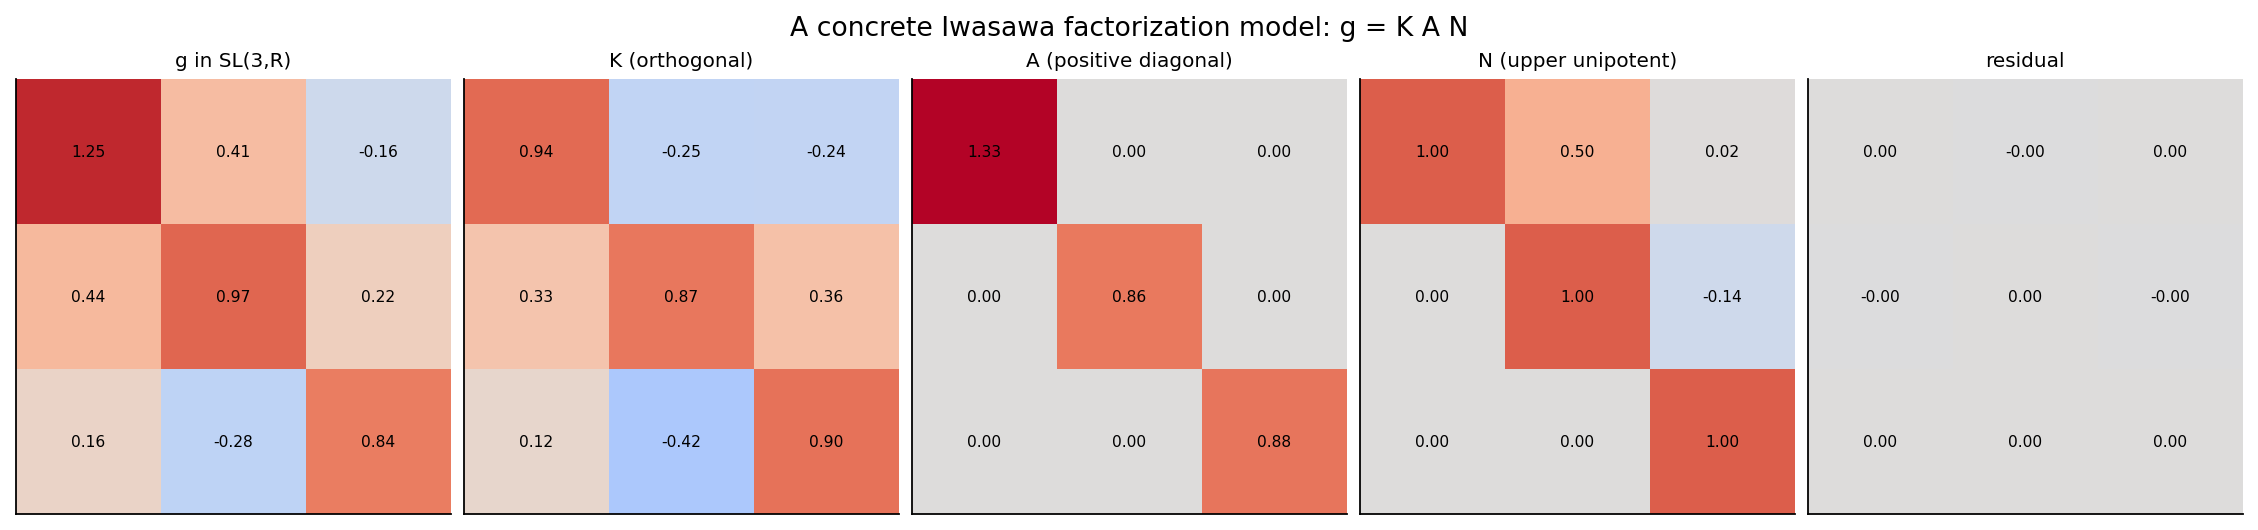

{'det_g': 1.0,
 'det_K': 1.0000000000000002,
 'det_A': 1.0000000000000002,
 'K_orthogonality_residual': 4.673304919261485e-16,
 'N_diagonal': [1.0, 1.0, 1.0],
 'N_lower_triangle_norm': 0.0,
 'reconstruction_residual': 2.1499376424746292e-16}

In [5]:
raw_g = np.array([
    [2.0, 0.65, -0.25],
    [0.70, 1.55, 0.35],
    [0.25, -0.45, 1.35],
])
det_raw = np.linalg.det(raw_g)
g_sl3 = raw_g / np.cbrt(det_raw)
Q, R = np.linalg.qr(g_sl3)
signs = np.sign(np.diag(R))
signs[signs == 0] = 1
S = np.diag(signs)
K_iwa = Q @ S
R_pos = S @ R
A_iwa = np.diag(np.diag(R_pos))
N_iwa = np.linalg.solve(A_iwa, R_pos)
reconstruction = K_iwa @ A_iwa @ N_iwa

matrices = [g_sl3, K_iwa, A_iwa, N_iwa, reconstruction - g_sl3]
titles = ["g in SL(3,R)", "K (orthogonal)", "A (positive diagonal)", "N (upper unipotent)", "residual"]
fig, axes = plt.subplots(1, 5, figsize=(14, 3.2), constrained_layout=True)
vmax = max(np.max(np.abs(m)) for m in matrices[:-1])
for ax, mat, title in zip(axes, matrices, titles):
    local_vmax = vmax if title != "residual" else max(np.max(np.abs(mat)), 1e-12)
    im = ax.imshow(mat, cmap="coolwarm", vmin=-local_vmax, vmax=local_vmax)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=9)
fig.suptitle("A concrete Iwasawa factorization model: g = K A N", y=1.05)
iwasawa_path = save_matplotlib(fig, FIGURES / "iwasawa-sl3-factorization.png")
plt.close(fig)

iwasawa_check = {
    "det_g": float(np.linalg.det(g_sl3)),
    "det_K": float(np.linalg.det(K_iwa)),
    "det_A": float(np.linalg.det(A_iwa)),
    "K_orthogonality_residual": float(np.linalg.norm(K_iwa.T @ K_iwa - np.eye(3))),
    "N_diagonal": np.diag(N_iwa).round(12).tolist(),
    "N_lower_triangle_norm": float(np.linalg.norm(np.tril(N_iwa, -1))),
    "reconstruction_residual": float(np.linalg.norm(reconstruction - g_sl3)),
}
iwasawa_check_path = save_json(iwasawa_check, CHECKS / "iwasawa-sl3-factorization.json")
display_artifact(iwasawa_path, width=900)
iwasawa_check


## 3. Bruhat Decomposition: Weyl Group Cells And The Big Cell

Bruhat decomposition replaces one global coordinate chart by a finite stratification indexed by the Weyl group. For `SL(3,R)`, the Weyl group is `S3`. The longest permutation is the open dense cell; shorter permutations lie on lower-dimensional boundary pieces.

Read the graph from bottom to top. Each cover increases inversion length by one, so the cell dimension grows toward the open cell.


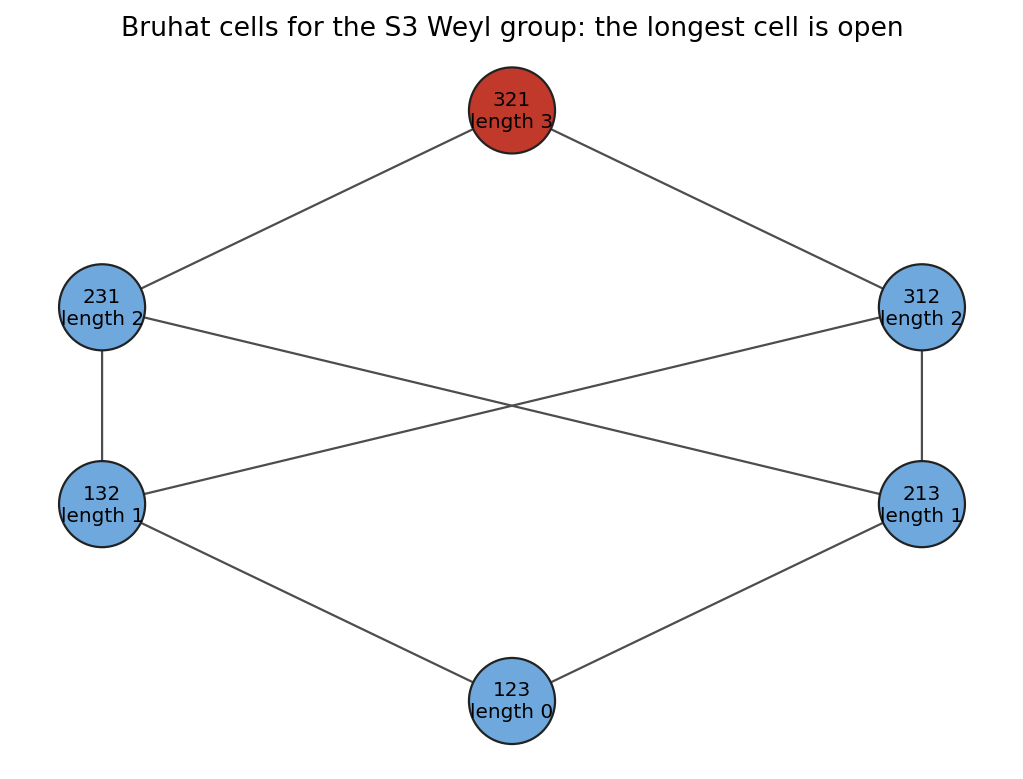

{'weyl_group': 'S3',
 'cell_count': 6,
 'length_counts': {0: 1, 1: 2, 2: 2, 3: 1},
 'longest_cells': ['321'],
 'open_cell_is_unique': True,
 'cover_edges_raise_length_by_one': True}

In [6]:
permutations = list(itertools.permutations([1, 2, 3]))

def inv_count(p):
    return sum(1 for i in range(len(p)) for j in range(i + 1, len(p)) if p[i] > p[j])

def label_perm(p):
    return "".join(str(x) for x in p)

bruhat_edges = [
    ((1, 2, 3), (2, 1, 3)),
    ((1, 2, 3), (1, 3, 2)),
    ((2, 1, 3), (2, 3, 1)),
    ((2, 1, 3), (3, 1, 2)),
    ((1, 3, 2), (2, 3, 1)),
    ((1, 3, 2), (3, 1, 2)),
    ((2, 3, 1), (3, 2, 1)),
    ((3, 1, 2), (3, 2, 1)),
]
BG = nx.DiGraph()
for p in permutations:
    BG.add_node(label_perm(p), length=inv_count(p), permutation=p)
BG.add_edges_from((label_perm(a), label_perm(b)) for a, b in bruhat_edges)
pos = {}
for length in range(4):
    nodes = sorted([node for node, data in BG.nodes(data=True) if data["length"] == length])
    for i, node in enumerate(nodes):
        pos[node] = (i - (len(nodes) - 1) / 2, length)

fig, ax = plt.subplots(figsize=(8, 5.8))
colors = ["#c0392b" if BG.nodes[n]["length"] == 3 else "#6fa8dc" for n in BG.nodes]
nx.draw_networkx_edges(BG, pos, ax=ax, arrows=True, arrowstyle="-|>", edge_color="#4d4d4d")
nx.draw_networkx_nodes(BG, pos, ax=ax, node_color=colors, node_size=1500, edgecolors="#222222")
labels = {node: f"{node}\nlength {BG.nodes[node]['length']}" for node in BG.nodes}
nx.draw_networkx_labels(BG, pos, labels=labels, ax=ax, font_size=9)
ax.set_title("Bruhat cells for the S3 Weyl group: the longest cell is open")
ax.set_axis_off()
bruhat_path = save_matplotlib(fig, FIGURES / "bruhat-s3-cell-order.png")
plt.close(fig)

length_counts = {length: sum(1 for p in permutations if inv_count(p) == length) for length in range(4)}
bruhat_check = {
    "weyl_group": "S3",
    "cell_count": len(permutations),
    "length_counts": length_counts,
    "longest_cells": [node for node, data in BG.nodes(data=True) if data["length"] == 3],
    "open_cell_is_unique": sum(1 for _, data in BG.nodes(data=True) if data["length"] == 3) == 1,
    "cover_edges_raise_length_by_one": all(BG.nodes[v]["length"] == BG.nodes[u]["length"] + 1 for u, v in BG.edges),
}
bruhat_check_path = save_json(bruhat_check, CHECKS / "bruhat-s3-cell-order.json")
display_artifact(bruhat_path, width=760)
bruhat_check


## 4. Rank-One Reduction: A Root String Becomes A Microscope

Chapter IX repeatedly reduces a large noncompact group to rank-one subgroups. For an indivisible positive restricted root `alpha`, the subalgebra generated by `g_alpha` and `g_-alpha` has only one noncompact direction in `a`. If `2 alpha` is present, the root string has five slots; if not, it collapses to the familiar `sl(2)` pattern.

The bracket degree rule is the visible invariant: a bracket of degrees `i` and `j` can only land in degree `i+j`, and it is zero when that degree is outside the root string.


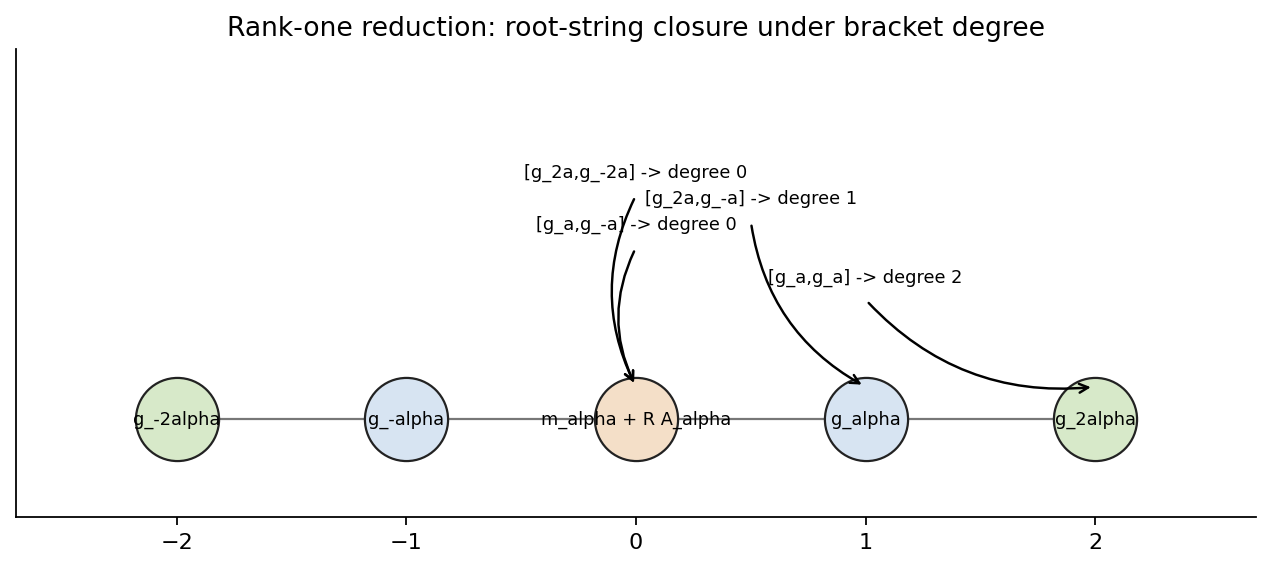

{'degrees': [-2, -1, 0, 1, 2],
 'positive_nilpotent_degrees': [1, 2],
 'rank_one_a_dimension': 1,
 'sample_rules': [{'left_degree': -2,
   'right_degree': -2,
   'target_degree': '0 outside string',
   'closed': True},
  {'left_degree': -2,
   'right_degree': -1,
   'target_degree': '0 outside string',
   'closed': True},
  {'left_degree': -2, 'right_degree': 0, 'target_degree': -2, 'closed': True},
  {'left_degree': -2, 'right_degree': 1, 'target_degree': -1, 'closed': True},
  {'left_degree': -2, 'right_degree': 2, 'target_degree': 0, 'closed': True},
  {'left_degree': -1, 'right_degree': -1, 'target_degree': -2, 'closed': True},
  {'left_degree': -1, 'right_degree': 0, 'target_degree': -1, 'closed': True},
  {'left_degree': -1, 'right_degree': 1, 'target_degree': 0, 'closed': True},
  {'left_degree': -1, 'right_degree': 2, 'target_degree': 1, 'closed': True},
  {'left_degree': 0, 'right_degree': 0, 'target_degree': 0, 'closed': True},
  {'left_degree': 0, 'right_degree': 1, 'target_

In [7]:
degrees = [-2, -1, 0, 1, 2]
root_labels = {
    -2: "g_-2alpha",
    -1: "g_-alpha",
    0: "m_alpha + R A_alpha",
    1: "g_alpha",
    2: "g_2alpha",
}
bracket_rules = []
for i in degrees:
    for j in degrees:
        if i <= j:
            target = i + j
            bracket_rules.append({
                "left_degree": i,
                "right_degree": j,
                "target_degree": target if target in degrees else "0 outside string",
                "closed": target in degrees or abs(target) > 2,
            })

fig, ax = plt.subplots(figsize=(10, 3.8))
y = 0
for degree in degrees:
    color = "#f4dfc8" if degree == 0 else ("#d7e4f2" if abs(degree) == 1 else "#d7e9c9")
    ax.scatter([degree], [y], s=1400, color=color, edgecolor="#222222", zorder=3)
    ax.text(degree, y, root_labels[degree], ha="center", va="center", fontsize=8)
ax.plot(degrees, [y] * len(degrees), color="#777777", lw=1)
arrows = [(-1, 1, 0, "[g_a,g_-a]"), (1, 1, 2, "[g_a,g_a]"), (2, -1, 1, "[g_2a,g_-a]"), (2, -2, 0, "[g_2a,g_-2a]")]
for left, right, target, label in arrows:
    mid = (left + right) / 2
    height = 0.55 + 0.12 * abs(left - right)
    ax.annotate("", xy=(target, 0.15), xytext=(mid, height), arrowprops={"arrowstyle": "->", "connectionstyle": "arc3,rad=0.25", "lw": 1.1})
    ax.text(mid, height + 0.08, label + f" -> degree {target}", ha="center", fontsize=8)
ax.set_xlim(-2.7, 2.7)
ax.set_ylim(-0.45, 1.7)
ax.set_xticks(degrees)
ax.set_yticks([])
ax.set_title("Rank-one reduction: root-string closure under bracket degree")
rank_one_path = save_matplotlib(fig, FIGURES / "rank-one-root-reduction.png")
plt.close(fig)

rank_one_check = {
    "degrees": degrees,
    "positive_nilpotent_degrees": [1, 2],
    "rank_one_a_dimension": 1,
    "sample_rules": bracket_rules,
    "displayed_rules_close_inside_string": all(rule["closed"] for rule in bracket_rules),
    "su11_fallback_when_2alpha_absent": True,
}
rank_one_check_path = save_json(rank_one_check, CHECKS / "rank-one-root-reduction.json")
display_artifact(rank_one_path, width=820)
rank_one_check


## 5. The `SU(2,1)` Reduction: Formula Surfaces

The rank-one case with both `alpha` and `2 alpha` is not just a slogan. It reduces the component functions to scalar expressions. In normalized coordinates, write `r^2 = c |X|^2` for the `g_alpha` part and `t^2 = c |Y|^2` for the `g_2alpha` part. The model below uses

`expH = (1 + r^2)^2 + 4 t^2`, `expB = r^4 + 4 t^2`, and `2 cosh(2A) = 2 expH - expB`.

Inspect the boundary: `expB` vanishes only at the identity parameter, which is exactly where the big-cell coordinate for `m* n` drops out.


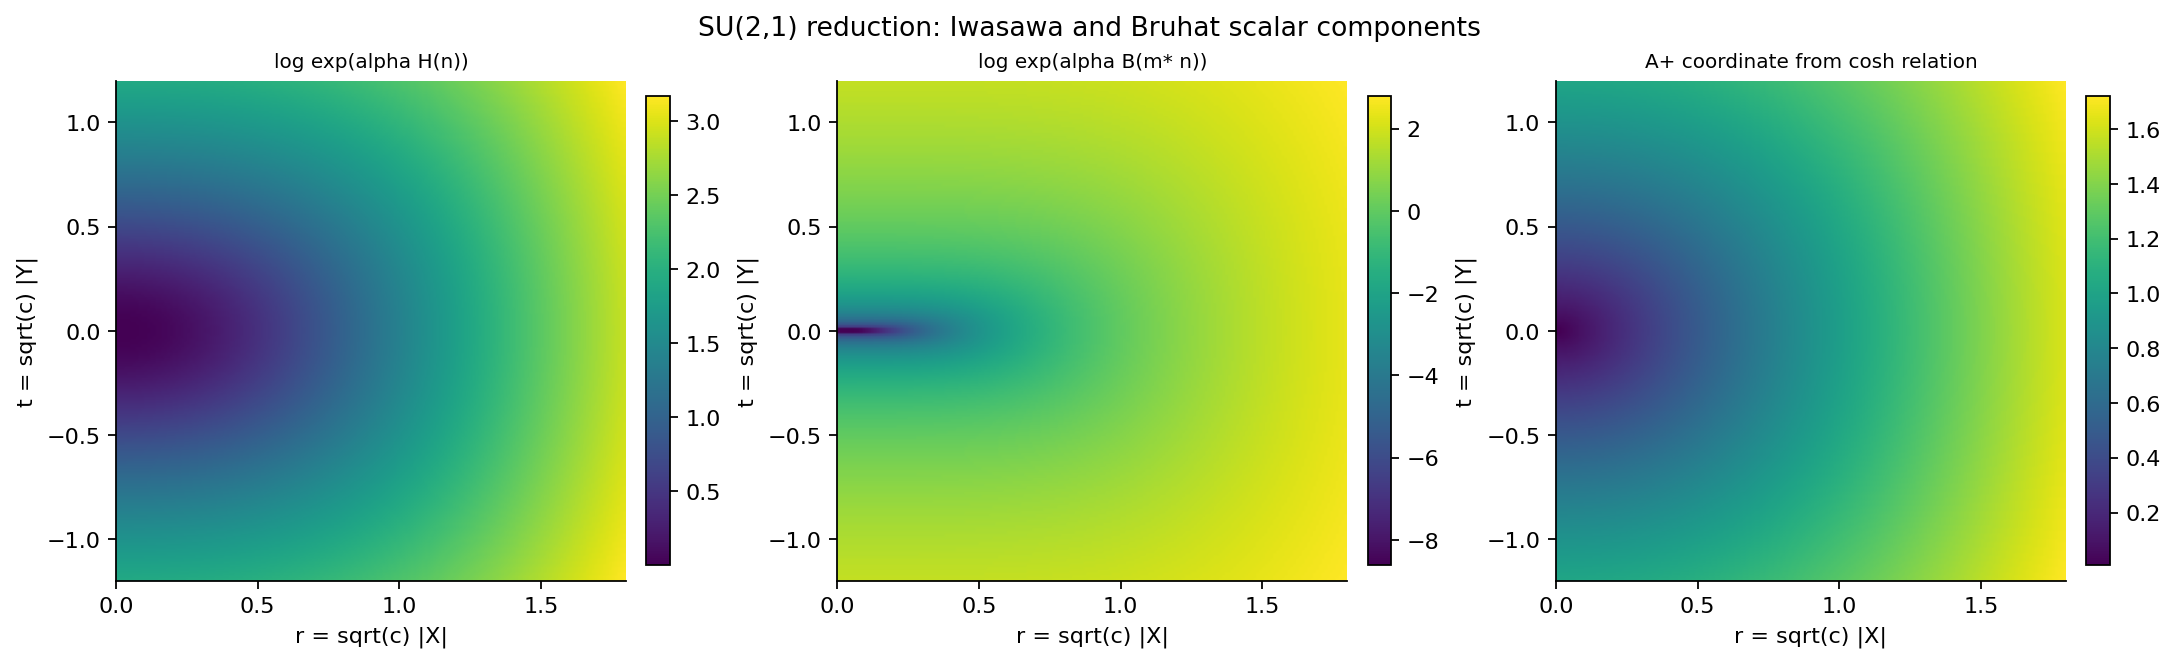

[su21-component-samples.csv](artifacts/chapter-09-structure-of-semisimple-lie-groups/tables/su21-component-samples.csv)

{'max_formula_residual': 0.0,
 'min_expH': 1.0001797696701102,
 'min_expB': 0.000179769670110165,
 'big_cell_boundary_grid_points': 0,
 'sample_count': 12}

In [8]:
r_values = np.linspace(0.0, 1.8, 180)
t_values = np.linspace(-1.2, 1.2, 180)
R, T = np.meshgrid(r_values, t_values)
r2 = R ** 2
expH = (1 + r2) ** 2 + 4 * T ** 2
expB = r2 ** 2 + 4 * T ** 2
two_cosh_2A = 2 * expH - expB
A_coord = 0.5 * np.arccosh(np.maximum(two_cosh_2A / 2, 1.0))
relation_residual = 2 * expH - expB - two_cosh_2A

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
panels = [
    (np.log(expH), "log exp(alpha H(n))"),
    (np.log(expB + 1e-12), "log exp(alpha B(m* n))"),
    (A_coord, "A+ coordinate from cosh relation"),
]
for ax, (data, title) in zip(axes, panels):
    im = ax.imshow(data, extent=[r_values.min(), r_values.max(), t_values.min(), t_values.max()], origin="lower", aspect="auto", cmap="viridis")
    ax.set_xlabel("r = sqrt(c) |X|")
    ax.set_ylabel("t = sqrt(c) |Y|")
    ax.set_title(title, fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("SU(2,1) reduction: Iwasawa and Bruhat scalar components", y=1.05)
su21_path = save_matplotlib(fig, FIGURES / "su21-iwasawa-bruhat-formulas.png")
plt.close(fig)

sample_rows = []
for r in [0.0, 0.4, 1.0, 1.6]:
    for t in [0.0, 0.35, 0.9]:
        eH = (1 + r ** 2) ** 2 + 4 * t ** 2
        eB = r ** 4 + 4 * t ** 2
        sample_rows.append({
            "r": r,
            "t": t,
            "exp_alpha_H": eH,
            "exp_alpha_B": eB,
            "two_cosh_2A": 2 * eH - eB,
            "in_big_cell": eB > 1e-12,
        })
su21_table_path = save_csv(sample_rows, TABLES / "su21-component-samples.csv")
su21_check = {
    "max_formula_residual": float(np.max(np.abs(relation_residual))),
    "min_expH": float(np.min(expH)),
    "min_expB": float(np.min(expB)),
    "big_cell_boundary_grid_points": int(np.sum(expB <= 1e-12)),
    "sample_count": len(sample_rows),
}
su21_check_path = save_json(su21_check, CHECKS / "su21-iwasawa-bruhat-formulas.json")
display_artifact(su21_path, width=900)
display_artifact(su21_table_path)
su21_check


## 6. Cartan Subalgebras And Root Automorphisms

A real Cartan subalgebra is not merely a maximal abelian subalgebra. Its elements must act semisimply after complexification. The `sl(2,R)` experiment separates three one-dimensional abelian subalgebras:

- the nilpotent line `R E`, maximal abelian but not Cartan;
- the split line `R H`, Cartan with real eigenvalues;
- the compact line `R J`, Cartan with imaginary eigenvalues.

The automorphism panel uses the `A2` root hexagon. Its full root-system automorphism group has twice the order of the Weyl group; the quotient records the diagram symmetry visible after chamber-folding.


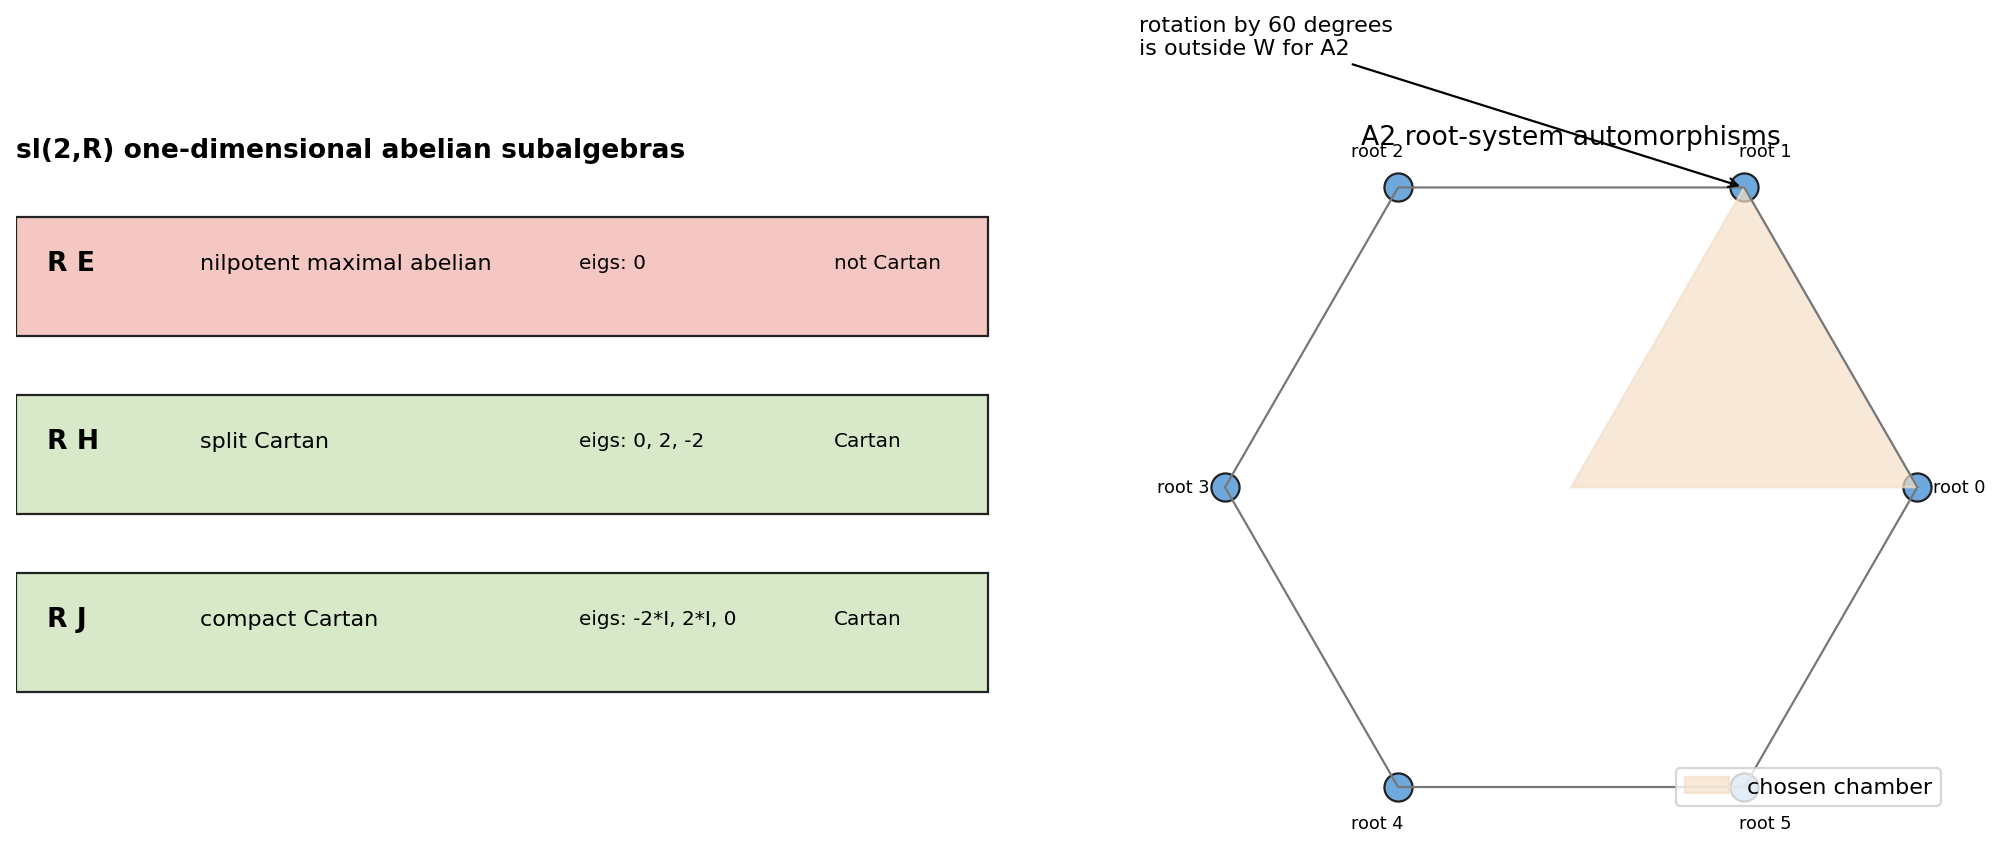

{'sl2_cases': [{'name': 'R E',
   'kind': 'nilpotent maximal abelian',
   'is_cartan': False,
   'ad_matrix': [['0', '0', '1'], ['-2', '0', '0'], ['0', '0', '0']],
   'eigenvalues': ['0'],
   'diagonalizable_over_C': False,
   'ad_nilpotent': True},
  {'name': 'R H',
   'kind': 'split Cartan',
   'is_cartan': True,
   'ad_matrix': [['0', '0', '0'], ['0', '2', '0'], ['0', '0', '-2']],
   'eigenvalues': ['0', '2', '-2'],
   'diagonalizable_over_C': True,
   'ad_nilpotent': False},
  {'name': 'R J',
   'kind': 'compact Cartan',
   'is_cartan': True,
   'ad_matrix': [['0', '-1', '-1'], ['2', '0', '0'], ['2', '0', '0']],
   'eigenvalues': ['-2*I', '2*I', '0'],
   'diagonalizable_over_C': True,
   'ad_nilpotent': False}],
 'automorphism_check': {'root_system': 'A2',
  'root_system_automorphism_order': 12,
  'weyl_group_order': 6,
  'outer_quotient_order': 2,
  'interpretation': 'Aut(Delta)/W detects the diagram symmetry for A2'},
 'nilpotent_line_not_cartan': True,
 'split_and_compact_lines_

In [9]:
H_sl2 = sp.Matrix([[1, 0], [0, -1]])
E_sl2 = sp.Matrix([[0, 1], [0, 0]])
F_sl2 = sp.Matrix([[0, 0], [1, 0]])
J_sl2 = F_sl2 - E_sl2
basis_sl2 = [H_sl2, E_sl2, F_sl2]

def bracket(A, B):
    return A * B - B * A

def coords_in_sl2(M):
    a, b, c = sp.symbols("a b c")
    expr = a * H_sl2 + b * E_sl2 + c * F_sl2 - M
    solution = sp.solve(list(expr), [a, b, c], dict=True)[0]
    return [sp.simplify(solution[a]), sp.simplify(solution[b]), sp.simplify(solution[c])]

def ad_matrix(X):
    columns = [coords_in_sl2(bracket(X, B)) for B in basis_sl2]
    return sp.Matrix.hstack(*[sp.Matrix(col) for col in columns])

cartan_cases = [
    {"name": "R E", "generator": E_sl2, "kind": "nilpotent maximal abelian", "is_cartan": False},
    {"name": "R H", "generator": H_sl2, "kind": "split Cartan", "is_cartan": True},
    {"name": "R J", "generator": J_sl2, "kind": "compact Cartan", "is_cartan": True},
]
for row in cartan_cases:
    ad = ad_matrix(row["generator"])
    row["ad_matrix"] = [[str(ad[i, j]) for j in range(3)] for i in range(3)]
    row["eigenvalues"] = [str(value) for value in ad.eigenvals().keys()]
    row["diagonalizable_over_C"] = bool(ad.is_diagonalizable(reals=False))
    row["ad_nilpotent"] = bool(ad ** 3 == sp.zeros(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)
ax = axes[0]
ax.axis("off")
y0 = 0.84
ax.text(0.0, 1.0, "sl(2,R) one-dimensional abelian subalgebras", fontsize=12, weight="bold", transform=ax.transAxes)
for idx, row in enumerate(cartan_cases):
    y = y0 - idx * 0.27
    color = "#d7e9c9" if row["is_cartan"] else "#f4c7c3"
    ax.add_patch(plt.Rectangle((0.0, y - 0.11), 0.95, 0.18, color=color, ec="#222222", transform=ax.transAxes))
    ax.text(0.03, y, row["name"], fontsize=12, weight="bold", transform=ax.transAxes, va="center")
    ax.text(0.18, y, row["kind"], transform=ax.transAxes, va="center")
    ax.text(0.55, y, "eigs: " + ", ".join(row["eigenvalues"]), transform=ax.transAxes, va="center", fontsize=9)
    ax.text(0.80, y, "Cartan" if row["is_cartan"] else "not Cartan", transform=ax.transAxes, va="center", fontsize=9)

ax = axes[1]
angles = np.linspace(0, 2 * np.pi, 7)[:-1]
roots_xy = np.c_[np.cos(angles), np.sin(angles)]
ax.plot(np.r_[roots_xy[:, 0], roots_xy[0, 0]], np.r_[roots_xy[:, 1], roots_xy[0, 1]], color="#777777", lw=1)
ax.scatter(roots_xy[:, 0], roots_xy[:, 1], s=160, color="#6fa8dc", edgecolor="#222222")
for i, (xv, yv) in enumerate(roots_xy):
    ax.text(1.12 * xv, 1.12 * yv, f"root {i}", ha="center", va="center", fontsize=8)
wedge = np.array([[0, 0], roots_xy[0], roots_xy[1]])
ax.fill(wedge[:, 0], wedge[:, 1], color="#f4dfc8", alpha=0.7, label="chosen chamber")
ax.annotate("rotation by 60 degrees\nis outside W for A2", xy=roots_xy[1], xytext=(-1.25, 1.25), arrowprops={"arrowstyle": "->"})
ax.set_aspect("equal")
ax.set_title("A2 root-system automorphisms")
ax.set_axis_off()
ax.legend(loc="lower right")
cartan_auto_path = save_matplotlib(fig, FIGURES / "cartan-subalgebra-and-root-automorphism.png")
plt.close(fig)

automorphism_check = {
    "root_system": "A2",
    "root_system_automorphism_order": 12,
    "weyl_group_order": 6,
    "outer_quotient_order": 2,
    "interpretation": "Aut(Delta)/W detects the diagram symmetry for A2",
}
cartan_auto_check = {
    "sl2_cases": [
        {key: value for key, value in row.items() if key != "generator"}
        for row in cartan_cases
    ],
    "automorphism_check": automorphism_check,
    "nilpotent_line_not_cartan": not cartan_cases[0]["is_cartan"] and cartan_cases[0]["ad_nilpotent"],
    "split_and_compact_lines_cartan": cartan_cases[1]["is_cartan"] and cartan_cases[2]["is_cartan"],
}
cartan_auto_check_path = save_json(cartan_auto_check, CHECKS / "cartan-subalgebra-and-root-automorphism.json")
display_artifact(cartan_auto_path, width=900)
cartan_auto_check


## 7. Multiplicity Parity And Split Rank

The multiplicity theorem links three things that look unrelated at first: conjugacy of Cartan subalgebras, a rank equality, and parity of restricted-root multiplicities. The ledger uses familiar symmetric-space families as checkpoints. It is not a classification table; it is a parity test bed.

The important habit is to read multiplicity as structure, not decoration. Odd multiplicity marks the obstruction in this theorem.


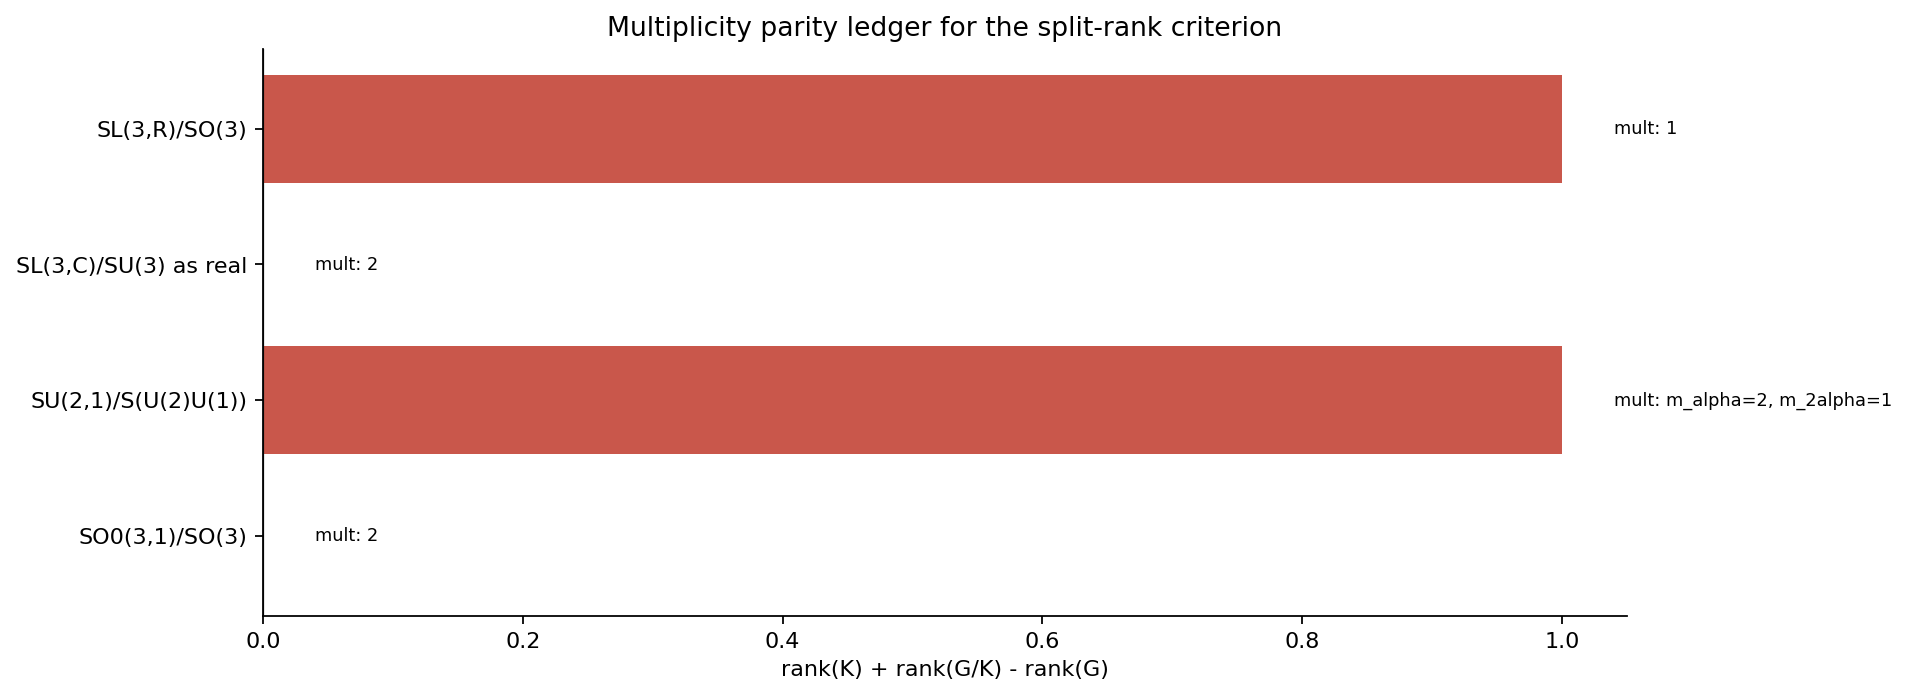

[multiplicity-parity-split-rank-ledger.csv](artifacts/chapter-09-structure-of-semisimple-lie-groups/tables/multiplicity-parity-split-rank-ledger.csv)

| space | rank_g | rank_k | rank_g_over_k | restricted_multiplicities | split_rank_equality | all_even |
| --- | --- | --- | --- | --- | --- | --- |
| SL(3,R)/SO(3) | 2 | 1 | 2 | 1 | False | False |
| SL(3,C)/SU(3) as real | 4 | 2 | 2 | 2 | True | True |
| SU(2,1)/S(U(2)U(1)) | 2 | 2 | 1 | m_alpha=2, m_2alpha=1 | False | False |
| SO0(3,1)/SO(3) | 2 | 1 | 1 | 2 | True | True |

{'row_count': 4,
 'all_rows_match_theorem_6_1_equivalence': True,
 'rows': [{'space': 'SL(3,R)/SO(3)',
   'rank_g': 2,
   'rank_k': 1,
   'rank_g_over_k': 2,
   'restricted_multiplicities': '1',
   'all_even': False,
   'split_rank_equality': False,
   'theorem_6_1_match': True},
  {'space': 'SL(3,C)/SU(3) as real',
   'rank_g': 4,
   'rank_k': 2,
   'rank_g_over_k': 2,
   'restricted_multiplicities': '2',
   'all_even': True,
   'split_rank_equality': True,
   'theorem_6_1_match': True},
  {'space': 'SU(2,1)/S(U(2)U(1))',
   'rank_g': 2,
   'rank_k': 2,
   'rank_g_over_k': 1,
   'restricted_multiplicities': 'm_alpha=2, m_2alpha=1',
   'all_even': False,
   'split_rank_equality': False,
   'theorem_6_1_match': True},
  {'space': 'SO0(3,1)/SO(3)',
   'rank_g': 2,
   'rank_k': 1,
   'rank_g_over_k': 1,
   'restricted_multiplicities': '2',
   'all_even': True,
   'split_rank_equality': True,
   'theorem_6_1_match': True}]}

In [10]:
multiplicity_rows = [
    {
        "space": "SL(3,R)/SO(3)",
        "rank_g": 2,
        "rank_k": 1,
        "rank_g_over_k": 2,
        "restricted_multiplicities": "1",
        "all_even": False,
    },
    {
        "space": "SL(3,C)/SU(3) as real",
        "rank_g": 4,
        "rank_k": 2,
        "rank_g_over_k": 2,
        "restricted_multiplicities": "2",
        "all_even": True,
    },
    {
        "space": "SU(2,1)/S(U(2)U(1))",
        "rank_g": 2,
        "rank_k": 2,
        "rank_g_over_k": 1,
        "restricted_multiplicities": "m_alpha=2, m_2alpha=1",
        "all_even": False,
    },
    {
        "space": "SO0(3,1)/SO(3)",
        "rank_g": 2,
        "rank_k": 1,
        "rank_g_over_k": 1,
        "restricted_multiplicities": "2",
        "all_even": True,
    },
]
for row in multiplicity_rows:
    row["split_rank_equality"] = row["rank_g"] == row["rank_k"] + row["rank_g_over_k"]
    row["theorem_6_1_match"] = row["split_rank_equality"] == row["all_even"]

fig, ax = plt.subplots(figsize=(11, 4.6))
y = np.arange(len(multiplicity_rows))
colors = ["#4c9f70" if row["all_even"] else "#c0392b" for row in multiplicity_rows]
values = [row["rank_k"] + row["rank_g_over_k"] - row["rank_g"] for row in multiplicity_rows]
ax.barh(y, values, color=colors, alpha=0.85)
ax.axvline(0, color="#222222", lw=1)
for yi, row, value in zip(y, multiplicity_rows, values):
    ax.text(value + (0.04 if value >= 0 else -0.04), yi, f"mult: {row['restricted_multiplicities']}", va="center", ha="left" if value >= 0 else "right", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels([row["space"] for row in multiplicity_rows])
ax.set_xlabel("rank(K) + rank(G/K) - rank(G)")
ax.set_title("Multiplicity parity ledger for the split-rank criterion")
ax.invert_yaxis()
multiplicity_path = save_matplotlib(fig, FIGURES / "multiplicity-parity-split-rank-ledger.png")
plt.close(fig)

multiplicity_table_path = save_csv(multiplicity_rows, TABLES / "multiplicity-parity-split-rank-ledger.csv")
multiplicity_check = {
    "row_count": len(multiplicity_rows),
    "all_rows_match_theorem_6_1_equivalence": all(row["theorem_6_1_match"] for row in multiplicity_rows),
    "rows": multiplicity_rows,
}
multiplicity_check_path = save_json(multiplicity_check, CHECKS / "multiplicity-parity-split-rank-ledger.json")
display_artifact(multiplicity_path, width=850)
display_artifact(multiplicity_table_path)
display_table(multiplicity_rows, ["space", "rank_g", "rank_k", "rank_g_over_k", "restricted_multiplicities", "split_rank_equality", "all_even"])
multiplicity_check


## 8. Jordan Pieces And The Nilpotent `sl2` Triple

Section 7 relates matrix Jordan decomposition to the `K A N` picture. Elliptic parts are compact-like, hyperbolic parts are `A`-like, and unipotent parts are `N`-like after conjugacy in the adjoint semisimple group.

The example builds a complete multiplicative Jordan decomposition with commuting pieces. The exact `sl(2,R)` check then models the theorem that a nonzero nilpotent element sits in a three-dimensional `sl2` subalgebra.


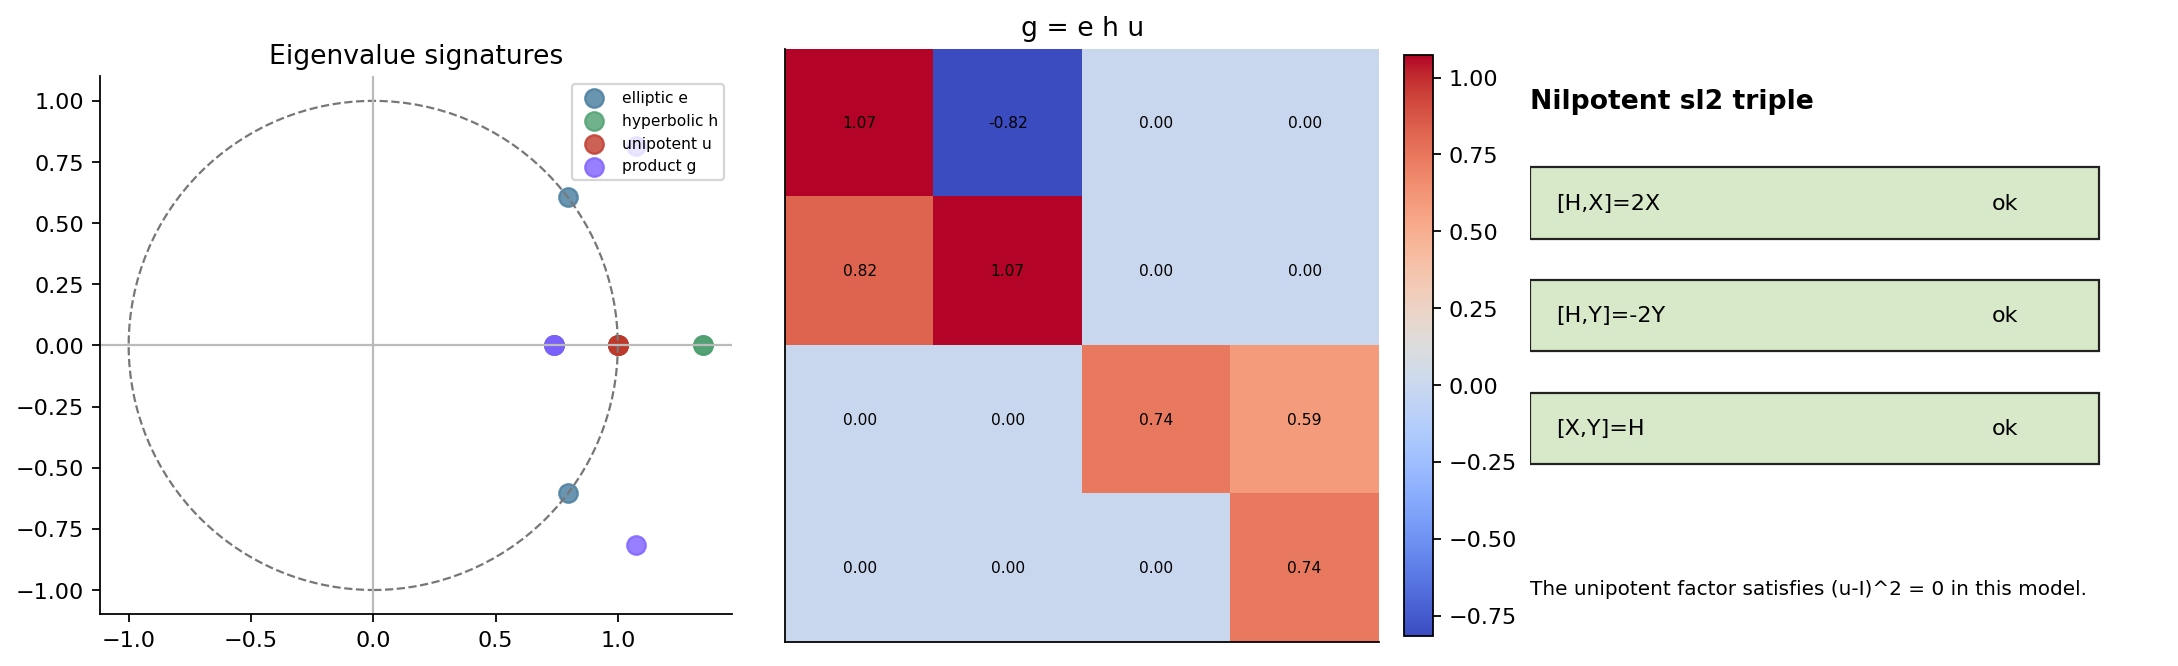

{'commutator_norms': {'EH_minus_HE': 0.0,
  'EU_minus_UE': 0.0,
  'HU_minus_UH': 0.0},
 'elliptic_moduli_all_one': True,
 'hyperbolic_eigenvalues_positive': True,
 'unipotent_eigenvalues_all_one': True,
 'unipotent_nilpotent_square_norm': 0.0,
 'sl2_triple': {'[H,X]=2X': True, '[H,Y]=-2Y': True, '[X,Y]=H': True}}

In [11]:
theta = 0.65
rotation = np.array([[math.cos(theta), -math.sin(theta)], [math.sin(theta), math.cos(theta)]])
E_part = np.eye(4)
E_part[:2, :2] = rotation
H_part = np.diag([1.35, 1.35, 0.74, 0.74])
U_part = np.eye(4)
U_part[2, 3] = 0.8
G_jordan = E_part @ H_part @ U_part

commutators = {
    "EH_minus_HE": float(np.linalg.norm(E_part @ H_part - H_part @ E_part)),
    "EU_minus_UE": float(np.linalg.norm(E_part @ U_part - U_part @ E_part)),
    "HU_minus_UH": float(np.linalg.norm(H_part @ U_part - U_part @ H_part)),
}
eig_data = {
    "elliptic_abs_eigenvalues": [float(abs(z)) for z in np.linalg.eigvals(E_part)],
    "hyperbolic_eigenvalues": [float(np.real(z)) for z in np.linalg.eigvals(H_part)],
    "unipotent_eigenvalues": [float(np.real(z)) for z in np.linalg.eigvals(U_part)],
    "g_eigenvalues": [[float(np.real(z)), float(np.imag(z))] for z in np.linalg.eigvals(G_jordan)],
}
nilpotent_part = U_part - np.eye(4)

X_nil = sp.Matrix([[0, 1], [0, 0]])
Y_nil = sp.Matrix([[0, 0], [1, 0]])
H_trip = sp.Matrix([[1, 0], [0, -1]])
sl2_triple = {
    "[H,X]=2X": bool(bracket(H_trip, X_nil) == 2 * X_nil),
    "[H,Y]=-2Y": bool(bracket(H_trip, Y_nil) == -2 * Y_nil),
    "[X,Y]=H": bool(bracket(X_nil, Y_nil) == H_trip),
}

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), constrained_layout=True)
component_names = ["elliptic e", "hyperbolic h", "unipotent u", "product g"]
component_mats = [E_part, H_part, U_part, G_jordan]
ax = axes[0]
for name, mat, color in zip(component_names, component_mats, ["#457b9d", "#4c9f70", "#c0392b", "#7d5fff"]):
    eigs = np.linalg.eigvals(mat)
    ax.scatter(np.real(eigs), np.imag(eigs), label=name, s=70, alpha=0.8, color=color)
circle = plt.Circle((0, 0), 1, fill=False, color="#777777", ls="--")
ax.add_patch(circle)
ax.axhline(0, color="#bbbbbb", lw=1)
ax.axvline(0, color="#bbbbbb", lw=1)
ax.set_aspect("equal")
ax.set_title("Eigenvalue signatures")
ax.legend(fontsize=7)

ax = axes[1]
im = ax.imshow(G_jordan, cmap="coolwarm")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{G_jordan[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("g = e h u")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[2]
ax.axis("off")
ax.text(0.0, 0.90, "Nilpotent sl2 triple", fontsize=12, weight="bold", transform=ax.transAxes)
for idx, (identity, ok) in enumerate(sl2_triple.items()):
    ax.add_patch(plt.Rectangle((0.0, 0.68 - idx * 0.19), 0.9, 0.12, color="#d7e9c9" if ok else "#f4c7c3", ec="#222222", transform=ax.transAxes))
    ax.text(0.04, 0.74 - idx * 0.19, identity, transform=ax.transAxes, va="center")
    ax.text(0.73, 0.74 - idx * 0.19, "ok" if ok else "fail", transform=ax.transAxes, va="center")
ax.text(0.0, 0.08, "The unipotent factor satisfies (u-I)^2 = 0 in this model.", fontsize=9, transform=ax.transAxes)

jordan_path = save_matplotlib(fig, FIGURES / "jordan-components-and-sl2-triple.png")
plt.close(fig)

jordan_check = {
    "commutator_norms": commutators,
    "elliptic_moduli_all_one": bool(np.allclose(eig_data["elliptic_abs_eigenvalues"], np.ones(4))),
    "hyperbolic_eigenvalues_positive": bool(all(value > 0 for value in eig_data["hyperbolic_eigenvalues"])),
    "unipotent_eigenvalues_all_one": bool(np.allclose(eig_data["unipotent_eigenvalues"], np.ones(4))),
    "unipotent_nilpotent_square_norm": float(np.linalg.norm(nilpotent_part @ nilpotent_part)),
    "sl2_triple": sl2_triple,
}
jordan_check_path = save_json(jordan_check, CHECKS / "jordan-components-and-sl2-triple.json")
display_artifact(jordan_path, width=900)
jordan_check


## Applied Lab: Move In The `SU(2,1)` Chart

The lab asks you to vary the two nilpotent coordinates. Increasing `r` turns on the `g_alpha` direction; increasing `|t|` turns on the `g_2alpha` direction. Watch how `H`, `B`, and `A+` respond.

Try these experiments:

1. Hold `t = 0` and increase `r`. Which component grows fastest?
2. Hold `r = 0` and increase `|t|`. Which term detects the big-cell boundary?
3. Find the one parameter pair in the grid that is not in the big cell for `m* n`.


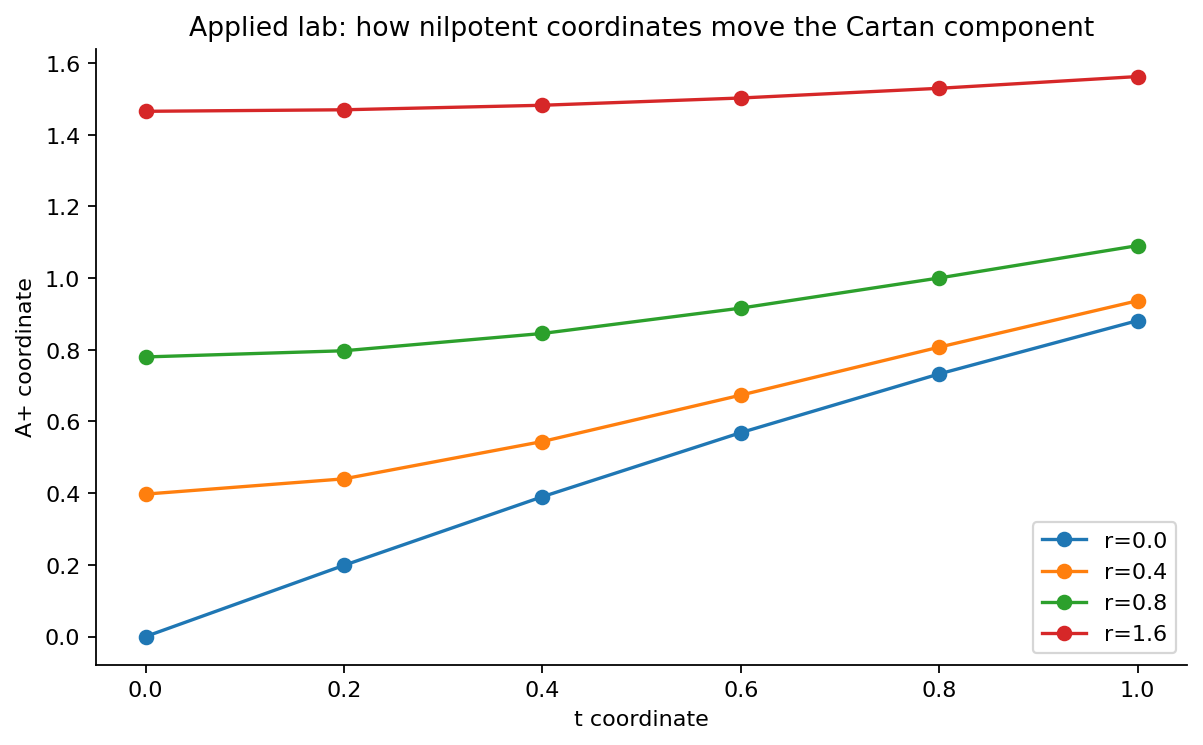

[su21-parameter-lab.csv](artifacts/chapter-09-structure-of-semisimple-lie-groups/tables/su21-parameter-lab.csv)

{'row_count': 54,
 'big_cell_failures': 1,
 'only_identity_misses_big_cell': True,
 'A_coordinate_monotone_at_t0': True}

In [12]:
lab_rows = []
for r in np.linspace(0, 1.6, 9):
    for t in np.linspace(0, 1.0, 6):
        eH = (1 + r ** 2) ** 2 + 4 * t ** 2
        eB = r ** 4 + 4 * t ** 2
        two_cosh = 2 * eH - eB
        lab_rows.append({
            "r": float(r),
            "t": float(t),
            "log_exp_alpha_H": float(math.log(eH)),
            "log_exp_alpha_B": float(math.log(eB)) if eB > 0 else float("-inf"),
            "A_coordinate": float(0.5 * math.acosh(max(two_cosh / 2, 1.0))),
            "in_big_cell": bool(eB > 1e-12),
        })
lab_table_path = save_csv(lab_rows, TABLES / "su21-parameter-lab.csv")

fig, ax = plt.subplots(figsize=(8.8, 5))
for r in [0.0, 0.4, 0.8, 1.6]:
    subset = [row for row in lab_rows if abs(row["r"] - r) < 1e-9]
    ax.plot([row["t"] for row in subset], [row["A_coordinate"] for row in subset], marker="o", label=f"r={r:.1f}")
ax.set_xlabel("t coordinate")
ax.set_ylabel("A+ coordinate")
ax.set_title("Applied lab: how nilpotent coordinates move the Cartan component")
ax.legend()
lab_path = save_matplotlib(fig, FIGURES / "applied-lab-su21-parameter-sweep.png")
plt.close(fig)

r_axis_rows = [row for row in lab_rows if row["t"] == 0.0]
lab_check = {
    "row_count": len(lab_rows),
    "big_cell_failures": sum(not row["in_big_cell"] for row in lab_rows),
    "only_identity_misses_big_cell": sum(not row["in_big_cell"] for row in lab_rows) == 1,
    "A_coordinate_monotone_at_t0": all(
        r_axis_rows[i]["A_coordinate"] <= r_axis_rows[i + 1]["A_coordinate"] + 1e-12
        for i in range(len(r_axis_rows) - 1)
    ),
}
lab_check_path = save_json(lab_check, CHECKS / "applied-lab-su21-parameter-sweep.json")
display_artifact(lab_path, width=760)
display_artifact(lab_table_path)
lab_check


## Takeaways

- The Cartan decomposition becomes unique only after folding into a closed Weyl chamber.
- Iwasawa decomposition is a coordinate system built from compact, abelian, and nilpotent directions.
- Bruhat decomposition is finite but not uniform: the longest Weyl element gives the open cell, while the other cells form lower-dimensional strata.
- Rank-one subalgebras are not side examples; they are the computational microscope behind the `SU(2,1)` formulas.
- Real Cartan subalgebras must be semisimple after complexification, which is why the nilpotent line in `sl(2,R)` fails.
- Automorphisms of compact real forms are controlled by root-system symmetries modulo Weyl symmetries.
- Multiplicity parity detects the split-rank criterion in Theorem 6.1.
- Jordan decomposition explains the group-theoretic roles of elliptic, hyperbolic, and unipotent elements: after conjugacy, they belong to the worlds of `K`, `A`, and `N`.


In [13]:
# final_sanity
expected_artifacts = [
    storyboard_path,
    source_coverage_path,
    routing_path,
    proof_graph_path,
    proof_graph_check_path,
    cartan_path,
    cartan_check_path,
    iwasawa_path,
    iwasawa_check_path,
    bruhat_path,
    bruhat_check_path,
    rank_one_path,
    rank_one_check_path,
    su21_path,
    su21_table_path,
    su21_check_path,
    cartan_auto_path,
    cartan_auto_check_path,
    multiplicity_path,
    multiplicity_table_path,
    multiplicity_check_path,
    jordan_path,
    jordan_check_path,
    lab_path,
    lab_table_path,
    lab_check_path,
]

sanity = {
    "unit": UNIT_TITLE,
    "source_span": "printed pages 401-437; approximate PDF pages 428-464",
    "artifact_count_before_final_file": len(expected_artifacts),
    "checks": {
        "proof_graph_connected": proof_graph_check["weakly_connected"],
        "proof_graph_acyclic": proof_graph_check["acyclic"],
        "cartan_unique_chamber_rep": cartan_check["unique_representatives_in_chamber"] == 1,
        "iwasawa_reconstruction_small": iwasawa_check["reconstruction_residual"] < 1e-10,
        "iwasawa_K_orthogonal": iwasawa_check["K_orthogonality_residual"] < 1e-10,
        "bruhat_has_six_cells": bruhat_check["cell_count"] == 6,
        "bruhat_open_cell_unique": bruhat_check["open_cell_is_unique"],
        "rank_one_degree_closure": rank_one_check["displayed_rules_close_inside_string"],
        "su21_formula_residual_small": su21_check["max_formula_residual"] < 1e-12,
        "cartan_classifier_ok": cartan_auto_check["nilpotent_line_not_cartan"] and cartan_auto_check["split_and_compact_lines_cartan"],
        "multiplicity_equivalence_rows_match": multiplicity_check["all_rows_match_theorem_6_1_equivalence"],
        "jordan_components_commute": max(jordan_check["commutator_norms"].values()) < 1e-12,
        "sl2_triple_holds": all(jordan_check["sl2_triple"].values()),
        "lab_only_identity_misses_big_cell": lab_check["only_identity_misses_big_cell"],
    },
}
sanity["all_checks_passed"] = all(sanity["checks"].values())
final_sanity_path = save_json(sanity, CHECKS / "final_sanity.json")
expected_artifacts.append(final_sanity_path)

assert_artifacts(expected_artifacts, min_bytes=80)
assert sanity["all_checks_passed"], sanity
display_artifact(final_sanity_path)
print(json.dumps(sanity, indent=2))


`final_sanity.json`

{
  "unit": "Structure of Semisimple Lie Groups",
  "source_span": "printed pages 401-437; approximate PDF pages 428-464",
  "artifact_count_before_final_file": 26,
  "checks": {
    "proof_graph_connected": true,
    "proof_graph_acyclic": true,
    "cartan_unique_chamber_rep": true,
    "iwasawa_reconstruction_small": true,
    "iwasawa_K_orthogonal": true,
    "bruhat_has_six_cells": true,
    "bruhat_open_cell_unique": true,
    "rank_one_degree_closure": true,
    "su21_formula_residual_small": true,
    "cartan_classifier_ok": true,
    "multiplicity_equivalence_rows_match": true,
    "jordan_components_commute": true,
    "sl2_triple_holds": true,
    "lab_only_identity_misses_big_cell": true
  },
  "all_checks_passed": true
}
